In [ ]:
# 
# CUSTOMER SEGMENTATION - RFM Analysis + K-Means Clustering


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load data
df = pd.read_csv("../data/raw/OnlineRetail.csv", encoding='latin1')

# Basic cleaning
df.dropna(subset=['CustomerID'], inplace=True)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Data loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Total customers: {df['CustomerID'].nunique():,}")

Data loaded successfully!
Total rows: 397,884
Total customers: 4,338


In [ ]:
# 
# RFM CALCULATION
# Recency   = how recently did customer buy?
# Frequency = how many times did they buy?
# Monetary  = how much total did they spend?


# Reference date = 1 day after last purchase in dataset
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo",   "nunique"),
    Monetary  = ("Revenue",     "sum")
).reset_index()

print("RFM Table:")
print(rfm.head(10))
print(f"\nShape: {rfm.shape}")
print(f"\nBasic Stats:")
print(rfm.describe())

RFM Table:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
5     12352.0       36          8   2506.04
6     12353.0      204          1     89.00
7     12354.0      232          1   1079.40
8     12355.0      214          1    459.40
9     12356.0       23          3   2811.43

Shape: (4338, 4)

Basic Stats:
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000 

In [ ]:

# SCALING
# We scale data so that all 3 values (R, F, M) are on 
# same range — otherwise Monetary (big numbers) will 
# dominate the clustering


scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Data scaled successfully!")
print(rfm_scaled.head())

Data scaled successfully!
    Recency  Frequency  Monetary
0  2.334574  -0.425097  8.358668
1 -0.905340   0.354417  0.250966
2 -0.175360  -0.035340 -0.028596
3 -0.735345  -0.425097 -0.033012
4  2.174578  -0.425097 -0.191347


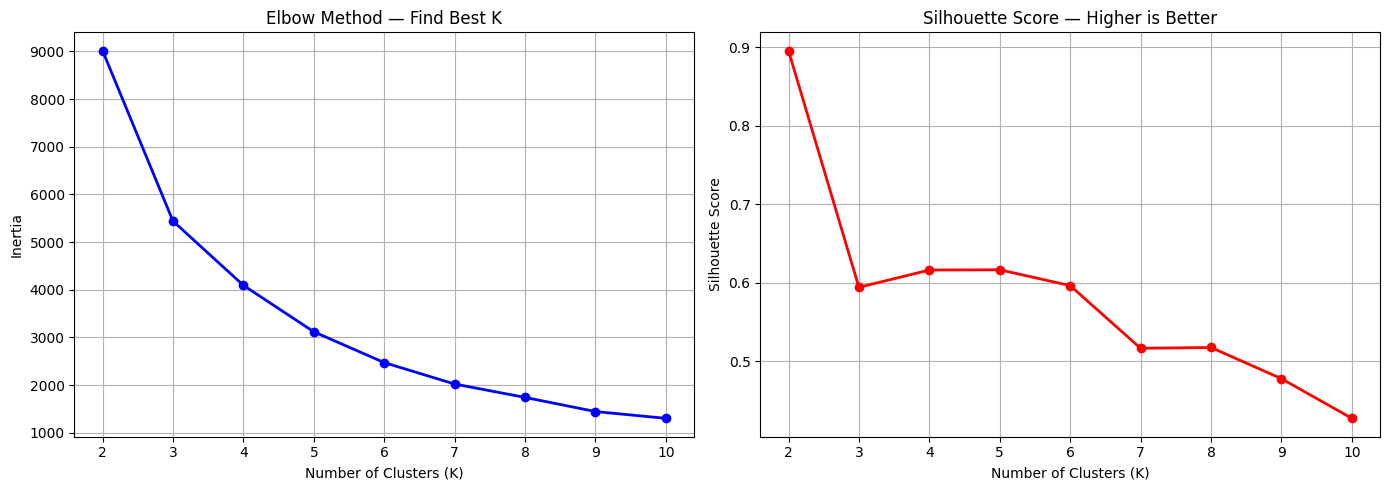


Best K by Silhouette Score: 2


In [ ]:

# ELBOW METHOD
# This helps us find the best number of customer groups
# We try K=2 to K=10 and see where the "elbow" is


inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertia, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Find Best K')
axes[0].grid(True)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Higher is Better')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nBest K by Silhouette Score: {K_range[silhouette_scores.index(max(silhouette_scores))]}")

In [ ]:

# K-MEANS CLUSTERING
# Based on elbow method we use K=4 (you can change this
# based on what the elbow graph showed you)


K = 4  # change this if your elbow/silhouette suggested different

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Summary of each cluster
cluster_summary = rfm.groupby('Cluster').agg(
    Customer_Count = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Avg_Monetary   = ('Monetary',   'mean')
).round(2)

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                          
0                  3054        43.70           3.68       1359.05
1                  1067       248.08           1.55        480.62
2                    13         7.38          82.54     127338.31
3                   204        15.50          22.33      12709.09


In [ ]:

# GIVING BUSINESS NAMES TO CLUSTERS


segment_map = {
    0: 'Regular Customers',
    1: 'Lost Customers',
    2: 'VIP Champions',
    3: 'Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Count per segment
print("Customer Segments:")
print(rfm['Segment'].value_counts())
print(f"\nTotal Customers: {len(rfm):,}")

Customer Segments:
Segment
Regular Customers    3054
Lost Customers       1067
Loyal Customers       204
VIP Champions          13
Name: count, dtype: int64

Total Customers: 4,338


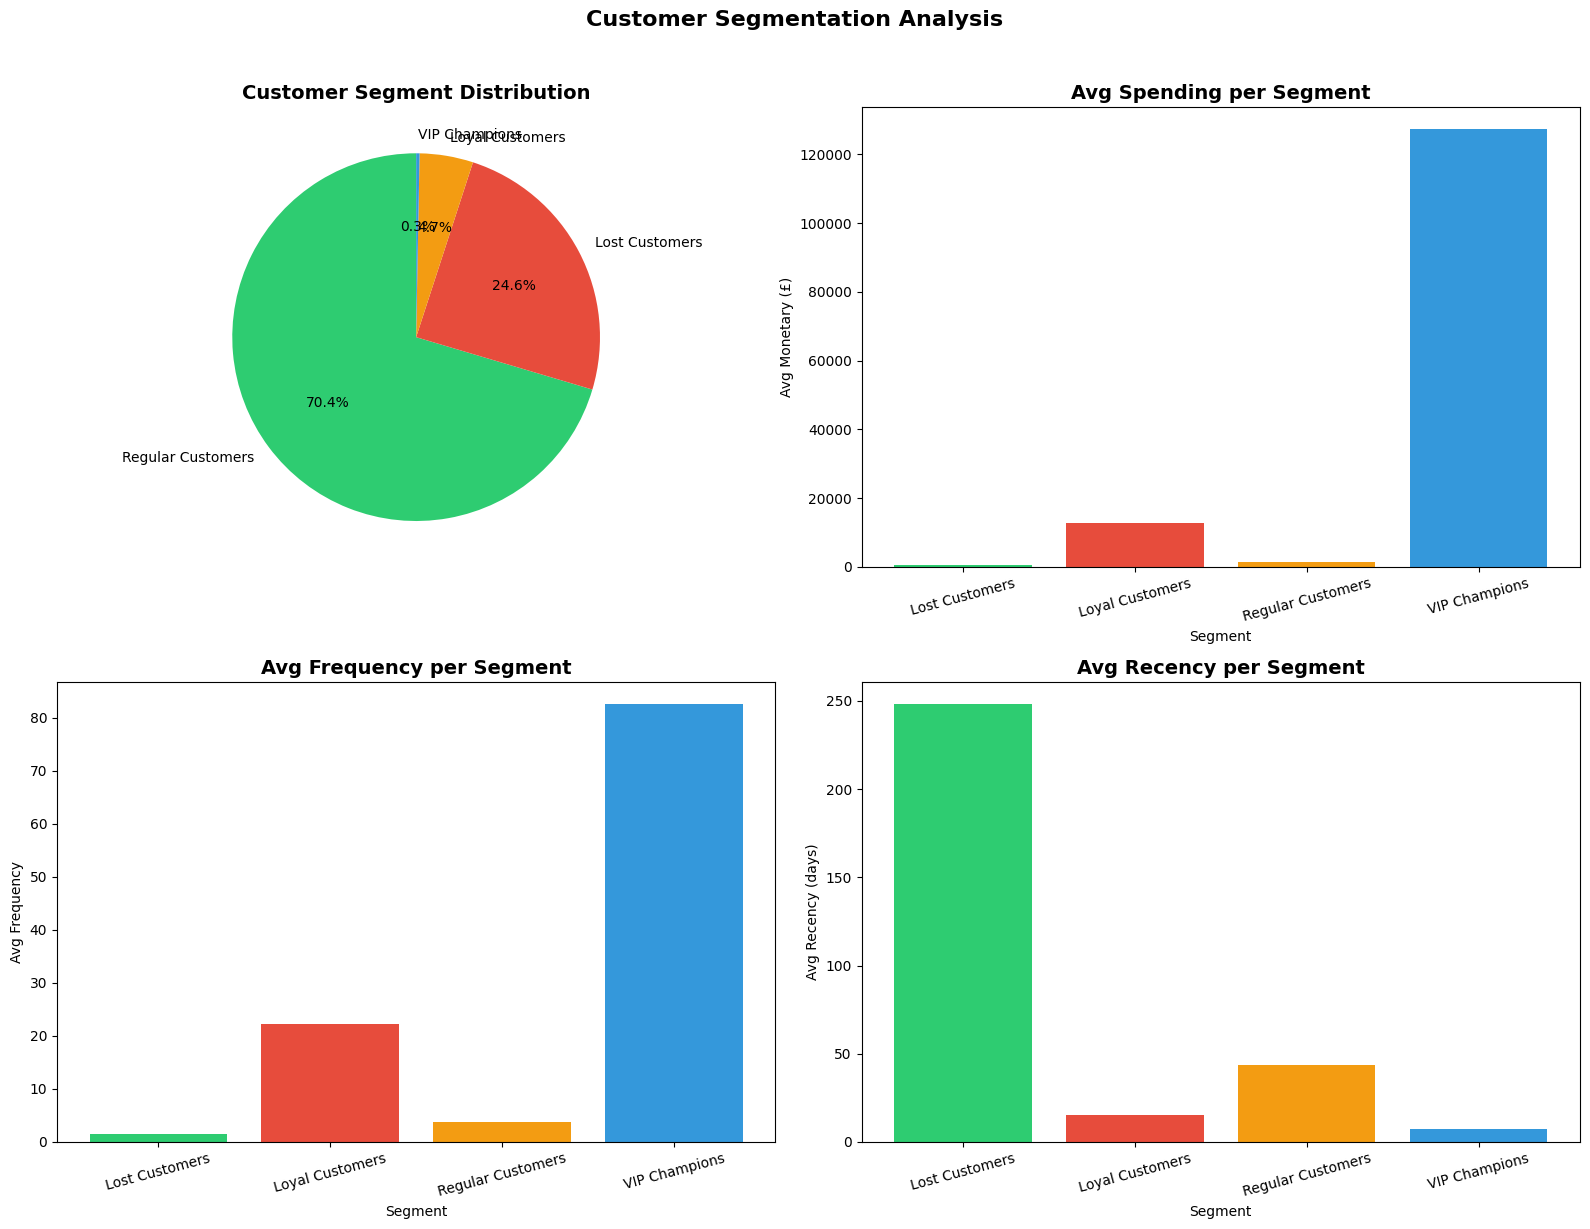

In [ ]:

# VISUALIZATION


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']

# 1. Pie chart - customer distribution
axes[0,0].pie(rfm['Segment'].value_counts(), 
              labels=rfm['Segment'].value_counts().index,
              autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')

# 2. Avg Monetary per segment
seg_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2)
axes[0,1].bar(seg_summary.index, seg_summary['Monetary'], color=colors)
axes[0,1].set_title('Avg Spending per Segment', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Avg Monetary (£)')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Avg Frequency per segment
axes[1,0].bar(seg_summary.index, seg_summary['Frequency'], color=colors)
axes[1,0].set_title('Avg Frequency per Segment', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Segment')
axes[1,0].set_ylabel('Avg Frequency')
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Avg Recency per segment
axes[1,1].bar(seg_summary.index, seg_summary['Recency'], color=colors)
axes[1,1].set_title('Avg Recency per Segment', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Segment')
axes[1,1].set_ylabel('Avg Recency (days)')
axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('Customer Segmentation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:

# SAVE RESULTS


# Save RFM + Segments to CSV
rfm.to_csv("../data/customer_segments.csv", index=False)

print("✅ Customer segments saved to data/customer_segments.csv")
print(f"\nFinal Summary:")
print(f"Total Customers Segmented : {len(rfm):,}")
print(f"VIP Champions             : {len(rfm[rfm['Segment']=='VIP Champions']):,}")
print(f"Loyal Customers           : {len(rfm[rfm['Segment']=='Loyal Customers']):,}")
print(f"Regular Customers         : {len(rfm[rfm['Segment']=='Regular Customers']):,}")
print(f"Lost Customers            : {len(rfm[rfm['Segment']=='Lost Customers']):,}")
print(f"\n✅ Customer Segmentation Complete!")

✅ Customer segments saved to data/customer_segments.csv

Final Summary:
Total Customers Segmented : 4,338
VIP Champions             : 13
Loyal Customers           : 204
Regular Customers         : 3,054
Lost Customers            : 1,067

✅ Customer Segmentation Complete!
